# 15 · Pipe flow of non-Newtonian fluids

Pumping drilling mud down a well, concrete up a building, slurries along a pipeline, sauces through a
factory: every one needs the pressure drop for a given flow rate. For non-Newtonian fluids the Newtonian
formulas fail - the velocity profile changes shape, a yield-stress fluid moves partly as a solid plug, and
the Reynolds number and friction factor need new definitions.

**What you will learn**
- compute velocity profiles, flow rates and pressure drops for power-law and yield-stress fluids
- use the Metzner-Reed Reynolds number to decide between laminar and turbulent flow
- size pumping for concrete and drilling mud
- estimate restart pressures for gelled lines

**Before you start:** notebooks 03-04; basic fluid mechanics (Hagen-Poiseuille, friction factors)  ·  **Time:** about 60-75 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import integrate
from engrheo import datasets, fitting, flows, geometry
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Velocity profiles at the same flow rate

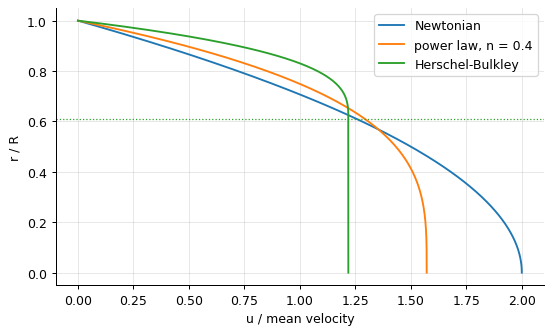

centre-line / mean velocity: Newtonian 2.00, power law 1.57; plug occupies r/R < 0.61


In [2]:
R, Q = 0.025, 1.5e-3                              # 5 cm pipe, 1.5 L/s
r = np.linspace(0, R, 400)
newt = flows.pipe_power_law(0.1, 1.0, R, Q=Q)
pl = flows.pipe_power_law(0.5, 0.4, R, Q=Q)
hb = flows.pipe_hb(8.0, 0.3, 0.5, R, Q=Q)
V = newt["V"]
plt.plot(flows.velocity_power_law(r, 0.1, 1.0, R, newt["dp_per_L"]) / V, r / R, label="Newtonian")
plt.plot(flows.velocity_power_law(r, 0.5, 0.4, R, pl["dp_per_L"]) / V, r / R, label="power law, n = 0.4")
plt.plot(flows.velocity_hb(r, 8.0, 0.3, 0.5, R, hb["dp_per_L"]) / V, r / R, label="Herschel-Bulkley")
plt.axhline(hb["plug_radius"] / R, color="C2", ls=":", lw=1)
plt.xlabel("u / mean velocity"); plt.ylabel("r / R"); plt.legend(); plt.show()
print(f"centre-line / mean velocity: Newtonian {newt['u_max']/V:.2f}, power law {pl['u_max']/V:.2f}; "
      f"plug occupies r/R < {hb['plug_radius']/R:.2f}")

Shear thinning flattens the profile: the fluid near the wall, where the shear rate is highest, becomes
thin and lubricates the core. A yield-stress fluid goes further - where the stress is below the yield
stress (near the axis) it moves as a rigid **plug**.

## Pumping concrete
Concrete is pumped along steel pipes to the top of high-rise buildings. How much pressure does the pump
need? The Bingham fit of notebook 04:

In [3]:
conc = pd.read_csv(datasets.path("concrete_flow_curve.csv"), comment="#")
b = fitting.fit_flow_curve(conc.shear_rate_1_s, conc.shear_stress_Pa, "bingham").params
Dp, Lp, Qc = 0.125, 100.0, 30 / 3600               # 125 mm line, 100 m, 30 m3/h
sol = flows.pipe_hb(b["tau_y"], b["mu_p"], 1.0, Dp / 2, Q=Qc)
dp = sol["dp_per_L"] * Lp
rho = 2350.0
Re = rho * sol["V"] * Dp / b["mu_p"]
print(f"mean velocity {sol['V']:.2f} m/s, Reynolds number {Re:.1f} (laminar)")
print(f"pressure drop over {Lp:.0f} m: {dp/1e5:.1f} bar; plug fills r/R < {sol['plug_radius']/(Dp/2):.2f}")
print(f"of which needed just to overcome the yield stress (4 tau_y L / D): {4*b['tau_y']*Lp/Dp/1e5:.1f} bar")

mean velocity 0.68 m/s, Reynolds number 4.6 (laminar)
pressure drop over 100 m: 86.5 bar; plug fills r/R < 0.23
of which needed just to overcome the yield stress (4 tau_y L / D): 20.0 bar


The flow is deeply laminar. At this flow rate the wall stress is several times the yield stress, so the
plug is small, and about a quarter of the pressure is spent overcoming the yield stress - the rest on the
plastic viscosity. Real concrete pressures are usually lower than this estimate: a thin,
cement-rich lubricating layer forms at the wall, and the concrete slides on it. Industrial practice therefore
uses tribometers and pumping tests; the calculation here is the no-slip upper bound.

## Drilling mud in the drill string: laminar or turbulent?
Mud is circulated down the drill pipe at high rates. Fitting a power law to the high-speed Fann readings
(the range relevant inside the pipe) gives the Metzner-Reed Reynolds number and the flow regime:

In [4]:
mud = pd.read_csv(datasets.path("drilling_mud_fann.csv"), comment="#")
tau_m, rate_m = geometry.fann35(mud.rpm.to_numpy(), mud.dial_reading_deg.to_numpy())
fast = rate_m >= 170                                  # 100-600 rpm
order = np.argsort(rate_m[fast])
pl_mud = fitting.fit_flow_curve(rate_m[fast][order], tau_m[fast][order], "power_law").params
D_pipe, rho_mud = 0.1086, 1200.0                      # 4.276 in inner diameter; 10 lb/gal mud
for q_gpm in (150, 300, 500):
    Qm = q_gpm * 6.309e-5                             # US gal/min -> m3/s
    res = flows.pressure_drop_power_law(Qm, D_pipe, 1000.0, rho_mud, pl_mud["K"], pl_mud["n"])
    print(f"{q_gpm} gal/min: V = {res['V']:.2f} m/s, Re_MR = {res['Re_MR']:8.0f} (critical {res['Re_critical']:.0f}) "
          f"-> {res['regime']:<9}, pressure loss {res['dp']/1e5:6.1f} bar per 1000 m")

150 gal/min: V = 1.02 m/s, Re_MR =      953 (critical 2392) -> laminar  , pressure loss    3.9 bar per 1000 m
300 gal/min: V = 2.04 m/s, Re_MR =     2770 (critical 2392) -> turbulent, pressure loss    6.6 bar per 1000 m
500 gal/min: V = 3.41 m/s, Re_MR =     6085 (critical 2392) -> turbulent, pressure loss   13.9 bar per 1000 m


At low rates the flow is laminar; at typical drilling rates it becomes turbulent and the pressure loss rises
steeply. The critical Reynolds number depends on $n$ (Ryan and Johnson): shear-thinning fluids stay laminar
somewhat longer than Newtonian ones.

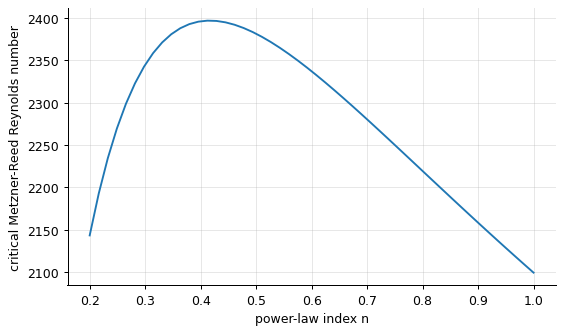

In [5]:
nn = np.linspace(0.2, 1.0, 50)
plt.plot(nn, [flows.critical_reynolds_power_law(v) for v in nn])
plt.xlabel("power-law index n"); plt.ylabel("critical Metzner-Reed Reynolds number"); plt.show()

## Restarting a gelled line
When circulation stops, a yield-stress fluid sets in the pipe. To restart flow, the pump must at least
overcome the yield stress along the whole line, $\Delta P_{start} = 4\tau_y L/D$ - independent of the flow rate:

In [6]:
hb_mud = fitting.fit_flow_curve(np.sort(rate_m), tau_m[np.argsort(rate_m)], "herschel_bulkley").params
for L_line in (1000.0, 3000.0):
    print(f"{L_line:.0f} m of 4.276 in pipe: at least {4*hb_mud['tau_y']*L_line/D_pipe/1e5:.1f} bar to restart "
          f"(yield stress {hb_mud['tau_y']:.1f} Pa)")

1000 m of 4.276 in pipe: at least 1.9 bar to restart (yield stress 5.2 Pa)
3000 m of 4.276 in pipe: at least 5.7 bar to restart (yield stress 5.2 Pa)


Many muds and waxy crude oils gel further while at rest (thixotropy, notebook 06), so their yield stress -
and the restart pressure - grows with the shut-in time; restart pressures are a key design question for
pipelines.

## Inside the algorithm: flow rate from the velocity profile
The flow rate is the velocity integrated over the cross-section, $Q = \int_0^R u(r)\,2\pi r\,dr$ - here for the
Herschel-Bulkley fluid, with the plug radius as a breakpoint:

In [7]:
Q_int = integrate.quad(lambda s: 2*np.pi*s*flows.velocity_hb(s, 8.0, 0.3, 0.5, R, hb["dp_per_L"]), 0, R,
                       points=[hb["plug_radius"]], epsabs=0, epsrel=1e-12)[0]
print(f"integrated profile {Q_int:.10e} m3/s, closed form {hb['Q']:.10e} m3/s (target {Q:.1e})")

integrated profile 1.5000000000e-03 m3/s, closed form 1.5000000000e-03 m3/s (target 1.5e-03)


## Exercises
1. How does the concrete pump pressure change if the line diameter is 100, 125 or 150 mm at 30 m³/h? Which part of the pressure (yield stress or viscous) depends most on the diameter?
2. For the drilling mud, double the flow rate from 250 to 500 gal/min. By what factor does the pressure loss grow, and how does that compare with the laminar power-law scaling $\Delta P \propto Q^n$?
3. **Implement it yourself:** write the Metzner-Reed Reynolds number from its definition and check, for the power-law fluid above, that $f = 16/Re_{MR}$ reproduces the exact laminar pressure gradient from `flows.pipe_power_law`.